In [ ]:
# Basic libraries
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Text processing
import re
import nltk

# Download stopwords
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [ ]:
# Loading dataset directly from GitHub (clean source)
url = "https://raw.githubusercontent.com/justmarkham/pycon-2016-tutorial/master/data/sms.tsv"

df = pd.read_csv(url, sep='\t', header=None, names=['label', 'message'])

df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [ ]:
print("Shape:", df.shape)
df.info()

Shape: (5572, 2)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    5572 non-null   object
 1   message  5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


In [ ]:
df['label'].value_counts()

,count
label,
ham,4825
spam,747


In [ ]:
df['label_num'] = df['label'].map({'ham': 0, 'spam': 1})
df.head()

,label,message,label_num
0,ham,"Go until jurong point, crazy.. Available only ...",0
1,ham,Ok lar... Joking wif u oni...,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,ham,U dun say so early hor... U c already then say...,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",0


In [ ]:
df.isnull().sum()

,0
label,0
message,0
label_num,0


In [ ]:
df['message_length'] = df['message'].apply(len)

## **Class Distribution Plot**

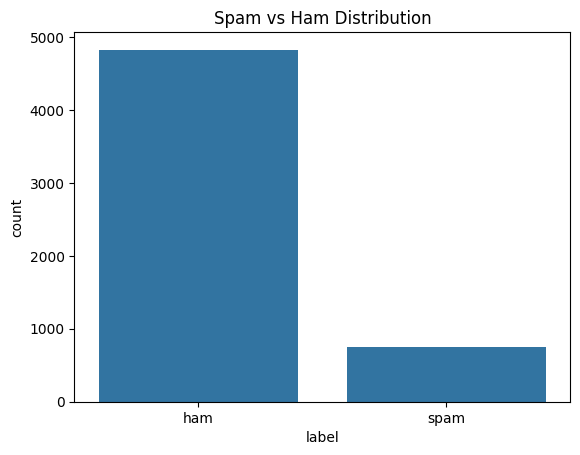

In [ ]:
sns.countplot(x='label', data=df)
plt.title("Spam vs Ham Distribution")
plt.show()

## **Message Length Distribution**

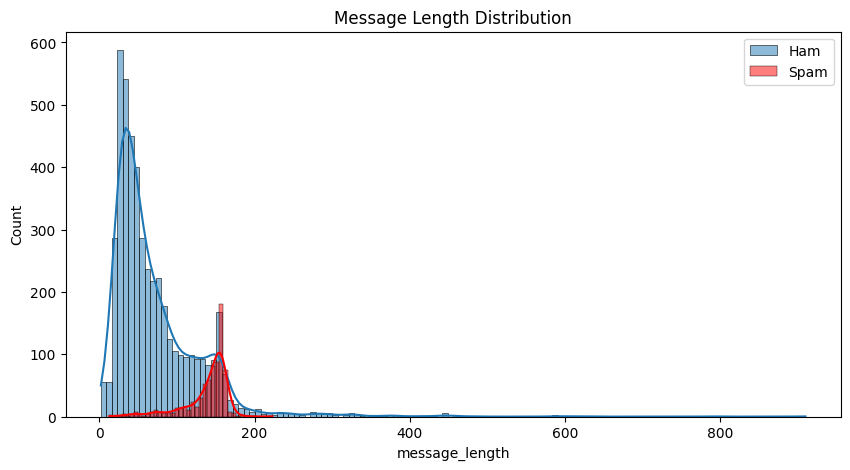

In [ ]:
plt.figure(figsize=(10,5))
sns.histplot(df[df['label']=='ham']['message_length'], label='Ham', kde=True)
sns.histplot(df[df['label']=='spam']['message_length'], label='Spam', kde=True, color='red')
plt.legend()
plt.title("Message Length Distribution")
plt.show()

## **Boxplot**

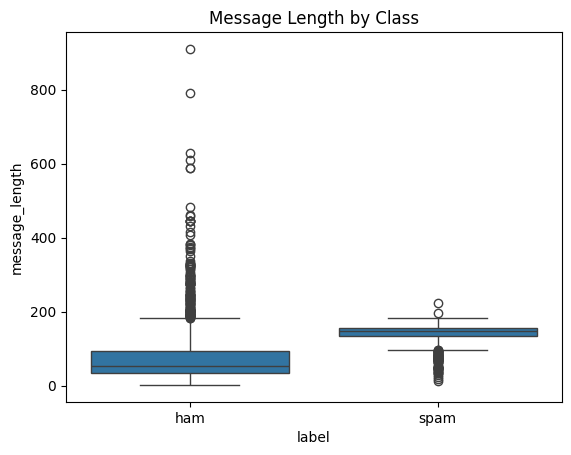

In [ ]:
sns.boxplot(x='label', y='message_length', data=df)
plt.title("Message Length by Class")
plt.show()

In [ ]:
df.to_csv("clean_spam_data.csv", index=False)

In [ ]:
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer

# Initialize
ps = PorterStemmer()
stop_words = set(stopwords.words('english'))

In [ ]:
def preprocess_text(text):
    # 1. Lowercase
    text = text.lower()

    # 2. Remove non-alphabet characters
    text = re.sub('[^a-z]', ' ', text)

    # 3. Tokenization
    words = text.split()

    # 4. Remove stopwords + stemming
    processed_words = []
    for word in words:
        if word not in stop_words:
            processed_words.append(ps.stem(word))

    # 5. Join back
    return " ".join(processed_words)

In [ ]:
sample = "Congratulations! You've won a FREE ticket to Bahamas!!! Call now!!!"

print("Original:", sample)
print("Processed:", preprocess_text(sample))

Original: Congratulations! You've won a FREE ticket to Bahamas!!! Call now!!!
Processed: congratul free ticket bahama call


In [ ]:
df['clean_text'] = df['message'].apply(preprocess_text)

df[['message', 'clean_text']].head()

,message,clean_text
0,"Go until jurong point, crazy.. Available only ...",go jurong point crazi avail bugi n great world...
1,Ok lar... Joking wif u oni...,ok lar joke wif u oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entri wkli comp win fa cup final tkt st m...
3,U dun say so early hor... U c already then say...,u dun say earli hor u c alreadi say
4,"Nah I don't think he goes to usf, he lives aro...",nah think goe usf live around though


In [ ]:
for i in range(5):
    print("Original:", df['message'][i])
    print("Cleaned :", df['clean_text'][i])
    print("-"*50)

Original: Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...
Cleaned : go jurong point crazi avail bugi n great world la e buffet cine got amor wat
--------------------------------------------------
Original: Ok lar... Joking wif u oni...
Cleaned : ok lar joke wif u oni
--------------------------------------------------
Original: Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's
Cleaned : free entri wkli comp win fa cup final tkt st may text fa receiv entri question std txt rate c appli
--------------------------------------------------
Original: U dun say so early hor... U c already then say...
Cleaned : u dun say earli hor u c alreadi say
--------------------------------------------------
Original: Nah I don't think he goes to usf, he lives around here though
Cleaned : nah think goe usf live around though
--------------

In [ ]:
(df['clean_text'] == "").sum()

np.int64(8)

In [ ]:
df.to_csv("processed_spam_data.csv", index=False)

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split

In [ ]:
X = df['clean_text']
y = df['label_num']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (4457,)
Test size: (1115,)


In [ ]:
cv = CountVectorizer(max_features=3000)

X_train_bow = cv.fit_transform(X_train)
X_test_bow = cv.transform(X_test)

In [ ]:
print(X_train_bow.shape)

(4457, 3000)


In [ ]:
tfidf = TfidfVectorizer(max_features=3000)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [ ]:
print(X_train_tfidf.shape)

(4457, 3000)


In [ ]:
print(list(tfidf.vocabulary_.keys())[:20])

['repli', 'win', 'weekli', 'world', 'cup', 'held', 'send', 'stop', 'end', 'servic', 'hello', 'sort', 'town', 'alreadi', 'dont', 'rush', 'home', 'eat', 'let', 'know']


In [ ]:
import pickle

pickle.dump(cv, open('count_vectorizer.pkl', 'wb'))
pickle.dump(tfidf, open('tfidf_vectorizer.pkl', 'wb'))

In [ ]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

In [ ]:
def evaluate_model(model, X_train, X_test, y_train, y_test):
    # Train
    model.fit(X_train, y_train)

    # Predict
    y_pred = model.predict(X_test)

    # Metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    return acc, prec, rec, f1

## **Model 1: Naive Bayes**

In [ ]:
nb = MultinomialNB()

nb_acc, nb_prec, nb_rec, nb_f1 = evaluate_model(
    nb, X_train_tfidf, X_test_tfidf, y_train, y_test
)

print("Naive Bayes Results:")
print("Accuracy :", nb_acc)
print("Precision:", nb_prec)
print("Recall   :", nb_rec)
print("F1 Score :", nb_f1)

Naive Bayes Results:
Accuracy : 0.979372197309417
Precision: 0.9921875
Recall   : 0.8523489932885906
F1 Score : 0.9169675090252708


## **Model 2: Logistic Regression**

In [ ]:
lr = LogisticRegression(max_iter=1000)

lr_acc, lr_prec, lr_rec, lr_f1 = evaluate_model(
    lr, X_train_tfidf, X_test_tfidf, y_train, y_test
)

print("\nLogistic Regression Results:")
print("Accuracy :", lr_acc)
print("Precision:", lr_prec)
print("Recall   :", lr_rec)
print("F1 Score :", lr_f1)


Logistic Regression Results:
Accuracy : 0.9730941704035875
Precision: 1.0
Recall   : 0.7986577181208053
F1 Score : 0.8880597014925373


## **Model 3: SVM**

In [ ]:
svm = SVC()

svm_acc, svm_prec, svm_rec, svm_f1 = evaluate_model(
    svm, X_train_tfidf, X_test_tfidf, y_train, y_test
)

print("\nSVM Results:")
print("Accuracy :", svm_acc)
print("Precision:", svm_prec)
print("Recall   :", svm_rec)
print("F1 Score :", svm_f1)


SVM Results:
Accuracy : 0.9829596412556054
Precision: 1.0
Recall   : 0.87248322147651
F1 Score : 0.931899641577061


In [ ]:
results = pd.DataFrame({
    'Model': ['Naive Bayes', 'Logistic Regression', 'SVM'],
    'Accuracy': [nb_acc, lr_acc, svm_acc],
    'Precision': [nb_prec, lr_prec, svm_prec],
    'Recall': [nb_rec, lr_rec, svm_rec],
    'F1 Score': [nb_f1, lr_f1, svm_f1]
})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Naive Bayes,0.979372,0.992188,0.852349,0.916968
1,Logistic Regression,0.973094,1.000000,0.798658,0.888060
2,SVM,0.982960,1.000000,0.872483,0.931900


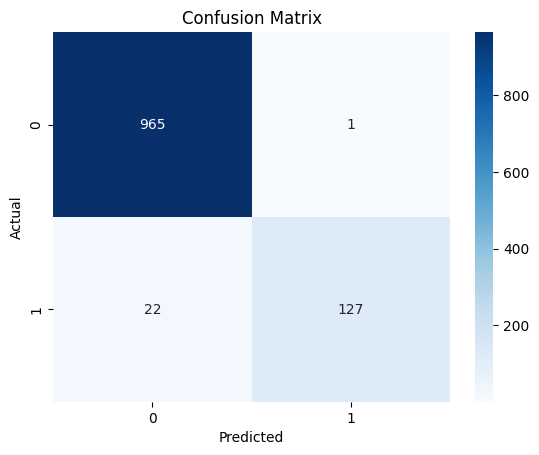

In [ ]:
best_model = nb  # change if needed

y_pred = best_model.predict(X_test_tfidf)

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
print(results.sort_values(by='F1 Score', ascending=False))

                 Model  Accuracy  Precision    Recall  F1 Score
2                  SVM  0.982960   1.000000  0.872483  0.931900
0          Naive Bayes  0.979372   0.992188  0.852349  0.916968
1  Logistic Regression  0.973094   1.000000  0.798658  0.888060


In [ ]:
pickle.dump(nb, open('spam_model.pkl', 'wb'))

In [40]:
from sklearn.svm import SVC

svm = SVC(probability=True)

svm.fit(X_train_tfidf, y_train)

pickle.dump(svm, open('spam_model.pkl', 'wb'))